# Questão 03 — Padrão de sobrevivência no TITANIC
Lista 2 — Inteligência Artificial — Profa. Cristiane Neri Nobre

Baseado no código `AD-Restaurante - codifica treina e avalia.ipynb`.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Leitura e primeira visualização da base

In [2]:
base = pd.read_csv('titanic completo.csv')
print(base.shape)
base.head()

(1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
base.info()
base.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
survived,1309.0,NaN,NaN,NaN,0.381971,0.486055,0.0,0.0,0.0,1.0,1.0
name,1309,1307,"Kelly, Mr. James",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Valores ausentes por atributo
base.isnull().sum().sort_values(ascending=False)

,0
body,1188
cabin,1014
boat,823
home.dest,564
age,263
embarked,2
fare,1
sibsp,0
name,0
survived,0


survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


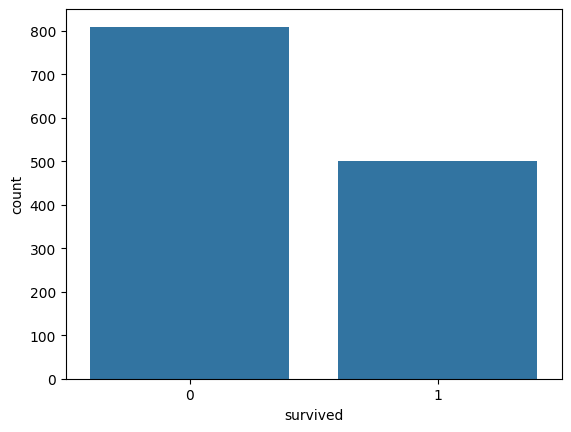

In [5]:
# Distribuição da classe
print(base['survived'].value_counts(normalize=True))
sns.countplot(x=base['survived']);

survived         0         1
sex                         
female    0.272532  0.727468
male      0.809015  0.190985
survived         0         1
pclass                      
1         0.380805  0.619195
2         0.570397  0.429603
3         0.744711  0.255289
survived         0         1
embarked                    
C         0.444444  0.555556
Q         0.642276  0.357724
S         0.667396  0.332604


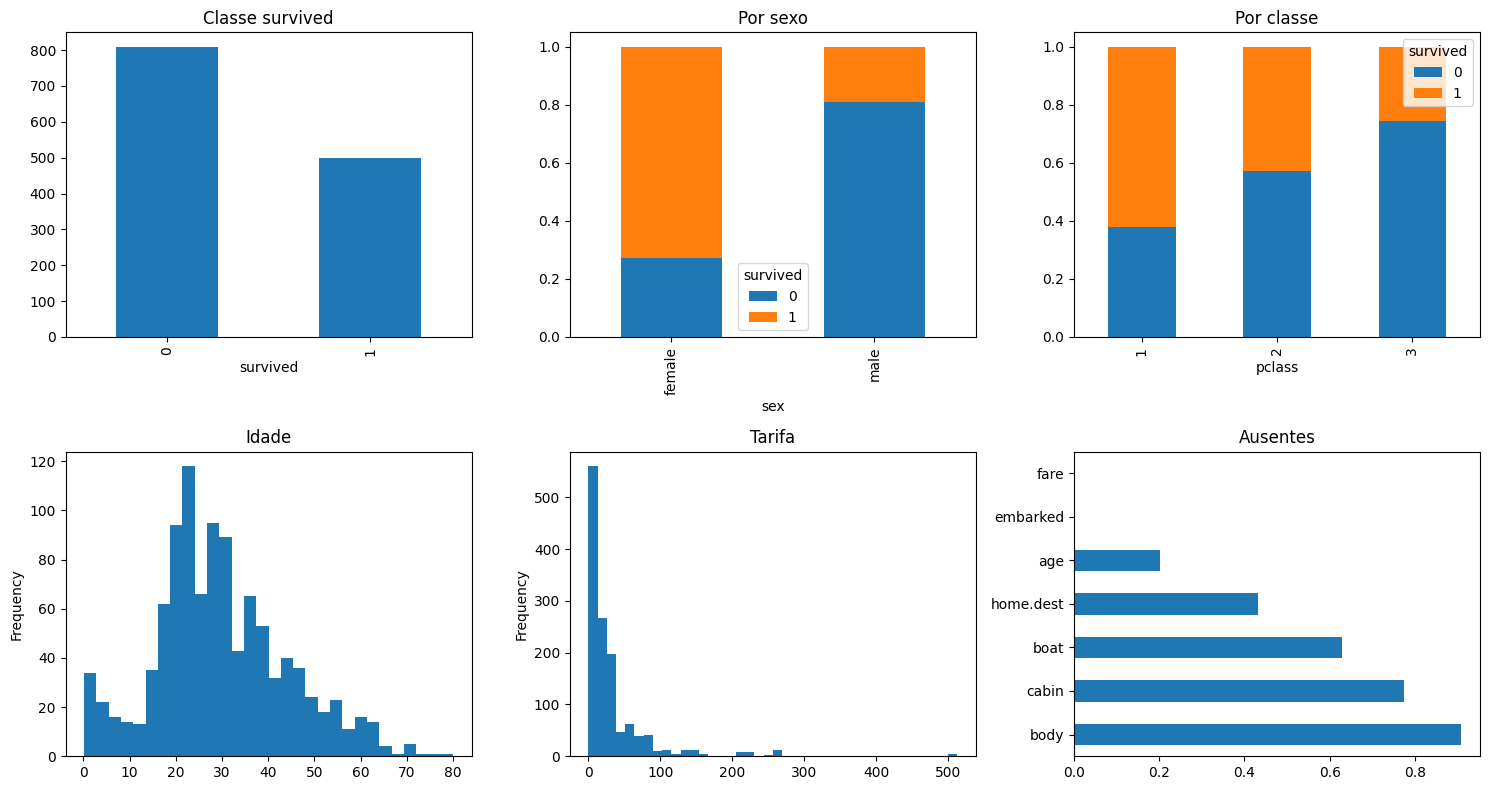

In [6]:
# Distribuições cruzadas com a classe
print(pd.crosstab(base.sex, base.survived, normalize='index'))
print(pd.crosstab(base.pclass, base.survived, normalize='index'))
print(pd.crosstab(base.embarked, base.survived, normalize='index'))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
base.survived.value_counts().sort_index().plot(kind='bar', ax=ax[0,0]); ax[0,0].set_title('Classe survived')
pd.crosstab(base.sex, base.survived, normalize='index').plot(kind='bar', stacked=True, ax=ax[0,1]); ax[0,1].set_title('Por sexo')
pd.crosstab(base.pclass, base.survived, normalize='index').plot(kind='bar', stacked=True, ax=ax[0,2]); ax[0,2].set_title('Por classe')
base.age.plot(kind='hist', bins=30, ax=ax[1,0]); ax[1,0].set_title('Idade')
base.fare.plot(kind='hist', bins=40, ax=ax[1,1]); ax[1,1].set_title('Tarifa')
base.isnull().mean().sort_values(ascending=False).head(7).plot(kind='barh', ax=ax[1,2]); ax[1,2].set_title('Ausentes')
plt.tight_layout()

## 3. Vazamento de dados (data leakage)
Os atributos `boat` (bote salva-vidas) e `body` (número do corpo recuperado) são **posteriores** ao naufrágio: quem tem `boat` preenchido embarcou em um bote e quem tem `body` preenchido morreu. Manter esses atributos gera acurácia próxima de 100%, mas o modelo não descobre padrão nenhum — apenas lê a resposta. Por isso ambos são removidos.

In [7]:
print(pd.crosstab(base.boat.notnull(), base.survived))
print(pd.crosstab(base.body.notnull(), base.survived))

survived    0    1
boat              
False     800   23
True        9  477
survived    0    1
body              
False     688  500
True      121    0


## 4. Codificação dos atributos

In [8]:
df = base.drop(columns=['boat', 'body', 'home.dest', 'ticket'])

# Título extraído do nome (proxy de sexo + idade + estado civil + status social)
def extrai_titulo(nome):
    t = re.search(r',\s*([^\.]*)\.', nome).group(1).strip()
    if t == 'Mr': return 'Mr'
    if t in ('Mrs', 'Mme', 'Lady', 'the Countess', 'Dona'): return 'Mrs'
    if t in ('Miss', 'Ms', 'Mlle'): return 'Miss'
    if t == 'Master': return 'Master'
    return 'Outros'

df['titulo'] = df['name'].apply(extrai_titulo)
print(pd.crosstab(df.titulo, df.survived, normalize='index'))

# cabin tem 77% de ausentes -> vira indicador binário
df['tem_cabine'] = df['cabin'].notnull().astype(int)
print(pd.crosstab(df.tem_cabine, df.survived, normalize='index'))

# Imputação
df['age']  = df.groupby('titulo')['age'].transform(lambda s: s.fillna(s.median()))
df['fare'] = df.groupby('pclass')['fare'].transform(lambda s: s.fillna(s.median()))
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Atributos derivados
df['tam_familia'] = df['sibsp'] + df['parch'] + 1
df['sozinho'] = (df['tam_familia'] == 1).astype(int)

# sex: binário (LabelEncoder equivale)
df['sexo'] = (df['sex'] == 'male').astype(int)   # 0 = feminino, 1 = masculino

# embarked e titulo: nominais -> OneHotEncoder (get_dummies)
X = pd.get_dummies(
        df[['pclass','sexo','age','sibsp','parch','fare','embarked',
            'titulo','tem_cabine','tam_familia','sozinho']],
        columns=['embarked','titulo'])

y = df['survived'].map({0: 'Nao sobreviveu', 1: 'Sobreviveu'})
X.head()

survived         0         1
titulo                      
Master    0.491803  0.508197
Miss      0.321970  0.678030
Mr        0.837517  0.162483
Mrs       0.208955  0.791045
Outros    0.692308  0.307692
survived           0         1
tem_cabine                    
0           0.697239  0.302761
1           0.345763  0.654237


,pclass,sexo,age,sibsp,parch,fare,tem_cabine,tam_familia,sozinho,embarked_C,embarked_Q,embarked_S,titulo_Master,titulo_Miss,titulo_Mr,titulo_Mrs,titulo_Outros
0,1,0,29.00,0,0,211.3375,1,1,1,False,False,True,False,True,False,False,False
1,1,1,0.92,1,2,151.5500,1,4,0,False,False,True,True,False,False,False,False
2,1,0,2.00,1,2,151.5500,1,4,0,False,False,True,False,True,False,False,False
3,1,1,30.00,1,2,151.5500,1,4,0,False,False,True,False,False,True,False,False
4,1,0,25.00,1,2,151.5500,1,4,0,False,False,True,False,False,False,True,False


## 5. Holdout estratificado

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=23, stratify=y)
print(X_treino.shape, X_teste.shape)

(916, 17) (393, 17)


## 6. Escolha da profundidade (controle de overfitting)

In [10]:
for d in [3, 4, 5, None]:
    m = DecisionTreeClassifier(criterion='entropy', max_depth=d,
                               min_samples_leaf=10, random_state=23)
    m.fit(X_treino, y_treino)
    cv = cross_val_score(m, X, y, cv=StratifiedKFold(10, shuffle=True, random_state=23)).mean()
    print(f'max_depth={d}: treino={m.score(X_treino,y_treino):.3f} '
          f'teste={m.score(X_teste,y_teste):.3f} cv10={cv:.3f}')

max_depth=3: treino=0.809 teste=0.807 cv10=0.810
max_depth=4: treino=0.817 teste=0.822 cv10=0.797
max_depth=5: treino=0.830 teste=0.804 cv10=0.798
max_depth=None: treino=0.846 teste=0.791 cv10=0.792


## 7. Modelo final e avaliação

In [11]:
modelo = DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                min_samples_leaf=10, random_state=23)
modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)

print('Acuracia:', accuracy_score(y_teste, previsoes))
print(confusion_matrix(y_teste, previsoes), modelo.classes_)
print(classification_report(y_teste, previsoes, digits=3))

Acuracia: 0.806615776081425
[[209  34]
 [ 42 108]] ['Nao sobreviveu' 'Sobreviveu']
                precision    recall  f1-score   support

Nao sobreviveu      0.833     0.860     0.846       243
    Sobreviveu      0.761     0.720     0.740       150

      accuracy                          0.807       393
     macro avg      0.797     0.790     0.793       393
  weighted avg      0.805     0.807     0.806       393



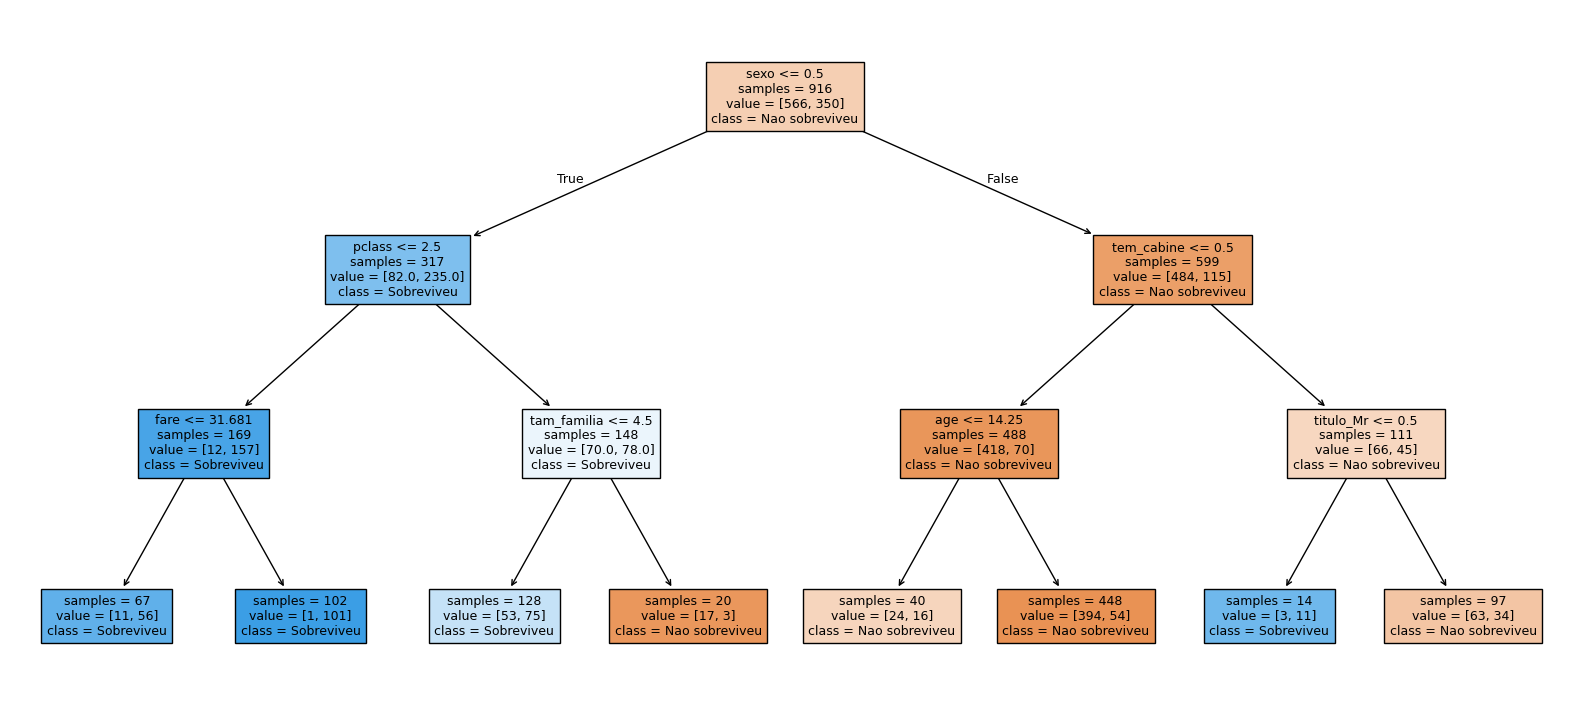

In [12]:
figura, eixos = plt.subplots(figsize=(20, 9))
plot_tree(modelo, feature_names=list(X.columns), class_names=modelo.classes_,
          filled=True, fontsize=9, impurity=False);

## 8. Regras extraídas e qualidade de cada regra

In [13]:
print(export_text(modelo, feature_names=list(X.columns)))

print('\nImportancia dos atributos:')
for a, v in sorted(zip(X.columns, modelo.feature_importances_), key=lambda t: -t[1]):
    if v > 0: print(f'  {a}: {v:.3f}')

|--- sexo <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 31.68
|   |   |   |--- class: Sobreviveu
|   |   |--- fare >  31.68
|   |   |   |--- class: Sobreviveu
|   |--- pclass >  2.50
|   |   |--- tam_familia <= 4.50
|   |   |   |--- class: Sobreviveu
|   |   |--- tam_familia >  4.50
|   |   |   |--- class: Nao sobreviveu
|--- sexo >  0.50
|   |--- tem_cabine <= 0.50
|   |   |--- age <= 14.25
|   |   |   |--- class: Nao sobreviveu
|   |   |--- age >  14.25
|   |   |   |--- class: Nao sobreviveu
|   |--- tem_cabine >  0.50
|   |   |--- titulo_Mr <= 0.50
|   |   |   |--- class: Sobreviveu
|   |   |--- titulo_Mr >  0.50
|   |   |   |--- class: Nao sobreviveu


Importancia dos atributos:
  sexo: 0.624
  pclass: 0.164
  tem_cabine: 0.080
  age: 0.041
  fare: 0.036
  tam_familia: 0.033
  titulo_Mr: 0.022


In [14]:
def qualidade_regras(Xd, yd, nome):
    d = pd.DataFrame({'folha': modelo.apply(Xd), 'y': yd.values, 'pred': modelo.predict(Xd)})
    print('===', nome, '===')
    for folha, g in d.groupby('folha'):
        c = g.pred.iloc[0]
        print(f'  folha {folha}: cobertura {len(g)}/{len(d)} ({len(g)/len(d):.1%}) '
              f'| classe = {c} | confianca = {(g.y==c).mean():.1%}')

qualidade_regras(X_treino, y_treino, 'TREINO')
qualidade_regras(X_teste,  y_teste,  'TESTE')

=== TREINO ===
  folha 3: cobertura 67/916 (7.3%) | classe = Sobreviveu | confianca = 83.6%
  folha 4: cobertura 102/916 (11.1%) | classe = Sobreviveu | confianca = 99.0%
  folha 6: cobertura 128/916 (14.0%) | classe = Sobreviveu | confianca = 58.6%
  folha 7: cobertura 20/916 (2.2%) | classe = Nao sobreviveu | confianca = 85.0%
  folha 10: cobertura 40/916 (4.4%) | classe = Nao sobreviveu | confianca = 60.0%
  folha 11: cobertura 448/916 (48.9%) | classe = Nao sobreviveu | confianca = 87.9%
  folha 13: cobertura 14/916 (1.5%) | classe = Sobreviveu | confianca = 78.6%
  folha 14: cobertura 97/916 (10.6%) | classe = Nao sobreviveu | confianca = 64.9%
=== TESTE ===
  folha 3: cobertura 38/393 (9.7%) | classe = Sobreviveu | confianca = 92.1%
  folha 4: cobertura 43/393 (10.9%) | classe = Sobreviveu | confianca = 95.3%
  folha 6: cobertura 56/393 (14.2%) | classe = Sobreviveu | confianca = 50.0%
  folha 7: cobertura 12/393 (3.1%) | classe = Nao sobreviveu | confianca = 100.0%
  folha 10: c